In [27]:
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd
import torch.nn as nn
import torch
from tqdm.autonotebook import tqdm
import seaborn as sns
import os, sys

from matplotlib.lines import Line2D
from collections import defaultdict
from matplotlib.colors import LinearSegmentedColormap
# Root project
project_root = os.path.abspath(os.path.join(os.getcwd(), "../../.."))

if project_root not in sys.path:
    sys.path.append(project_root)

print("Project root added to sys.path:", project_root)

from envs import *
from basal_ganglia import *
from stn_gpe import *

# filter warnings
import warnings
warnings.filterwarnings("ignore")
import pickle

Project root added to sys.path: /Users/charithapalika/Desktop/Lab projects/Decision Making/Light_House_DBS/light_house_DBS_decision_making


In [28]:
yaml_path = os.path.join(project_root, 'params', 'decision_making_task_params', 'igt', 'params.yaml')
params = load_yaml(yaml_path)
STN_DATA_path = os.path.join(project_root, 'params', 'stn_gpe_params', 'params_Normal.yaml')

## Hyperparameters


In [29]:
TRIALS = params['TRIALS']
EPOCHS = params['EPOCHS']
NUM_BINS = params['NUM_BINS']
LR = 0.1 #0.0075 #params['LR']
NUM_ARMS = params['NUM_ARMS']
SCALING_FACTOR = params['SCALING_FACTOR']
REW_STD = 0
LOSS_STD = 0

## Simulation

In [30]:
env = IGTEnv(mean_reward=np.array([100,100,50,50])/SCALING_FACTOR,
             std_reward=np.array([REW_STD,REW_STD,REW_STD,REW_STD])/SCALING_FACTOR,
             mean_loss=np.array([-250,-1250,-50,-250])/SCALING_FACTOR,
             std_loss=np.array([LOSS_STD,LOSS_STD,LOSS_STD,LOSS_STD])/SCALING_FACTOR)

In [31]:

reward_monitor, arm_chosen_monitor, avg_counts,ip_monitor, dp_monitor, ep_monitor, _= train(env, 
                                                      trails = TRIALS, 
                                                      epochs = EPOCHS, 
                                                      lr = LR, 
                                                      bins = NUM_BINS,
                                                      STN_data = STN_DATA_path, 
                                                      d1_amp=0.5, #0.005, #0.5,
                                                      d2_amp=0.01, #0.0015,#0.02, #0.035, #1
                                                      gpi_threshold=0.15,#0.18,
                                                      max_gpi_iters=50,
                                                      del_lim=None, train_IP = False, 
                                                      del_med = None, printing = False ,
                                                      gpi_mean= 1, ep_0 = 0.15, alpha_ep = 0.0,
                                                      eta_ep = 0.1,
                                                      baseline_ep = 0.0)
                                                    


Running STN-GPe system


  0%|          | 0/50000 [00:00<?, ?it/s]

StdDev of STN: 0.3233731577237562, Mean of STN: 1.0


  0%|          | 0/100 [00:00<?, ?it/s]

## Analysis

In [32]:
A_picks = avg_counts[0]
B_picks = avg_counts[1]
C_picks = avg_counts[2]
D_picks = avg_counts[3]

Avg_A_picks = torch.mean(A_picks, dim = 0)
Avg_B_picks = torch.mean(B_picks, dim = 0)
Avg_C_picks = torch.mean(C_picks, dim = 0)
Avg_D_picks = torch.mean(D_picks, dim = 0)

IGT_score = torch.mean(torch.add(C_picks, D_picks) - torch.add(A_picks, B_picks), dim = 0).squeeze().numpy()
IGT_dev = torch.std(torch.add(C_picks, D_picks) - torch.add(A_picks, B_picks), dim = 0)/torch.sqrt(torch.tensor(EPOCHS, dtype = torch.float32))
IGT_dev = IGT_dev.squeeze().numpy()

print(f'IGT score: {IGT_score} with SE of {IGT_dev}')

IGT score: [-0.24  2.86  4.08  4.06  4.44] with SE of [1.7144142 1.744777  1.6696749 1.5871848 1.5953417]


In [33]:
A_picks = avg_counts[0]
B_picks = avg_counts[1]
C_picks = avg_counts[2]
D_picks = avg_counts[3]

Avg_A_picks = torch.mean(A_picks, dim = 0)
Avg_B_picks = torch.mean(B_picks, dim = 0)
Avg_C_picks = torch.mean(C_picks, dim = 0)
Avg_D_picks = torch.mean(D_picks, dim = 0)

IP_A = torch.mean(ip_monitor[0], dim = 0).detach().numpy()
IP_B = torch.mean(ip_monitor[1], dim = 0).detach().numpy()
IP_C = torch.mean(ip_monitor[2], dim = 0).detach().numpy()
IP_D = torch.mean(ip_monitor[3], dim = 0).detach().numpy()

DP_A = torch.mean(dp_monitor[0], dim = 0).detach().numpy()
DP_B = torch.mean(dp_monitor[1], dim = 0).detach().numpy()
DP_C = torch.mean(dp_monitor[2], dim = 0).detach().numpy()
DP_D = torch.mean(dp_monitor[3], dim = 0).detach().numpy()

IGT_score = torch.mean(torch.add(C_picks, D_picks) - torch.add(A_picks, B_picks), dim = 0)
IGT_dev = torch.std(torch.add(C_picks, D_picks) - torch.add(A_picks, B_picks), dim = 0)/torch.sqrt(torch.tensor(EPOCHS, dtype = torch.float32))


DP_all = np.array([DP_A[:,0],DP_B[:,0],DP_C[:,0],DP_D[:,0]])
IP_all = np.array([IP_A[:,0],IP_B[:,0],IP_C[:,0],IP_D[:,0]])
IP_Var = np.std(IP_all,axis = 0 )

## Results

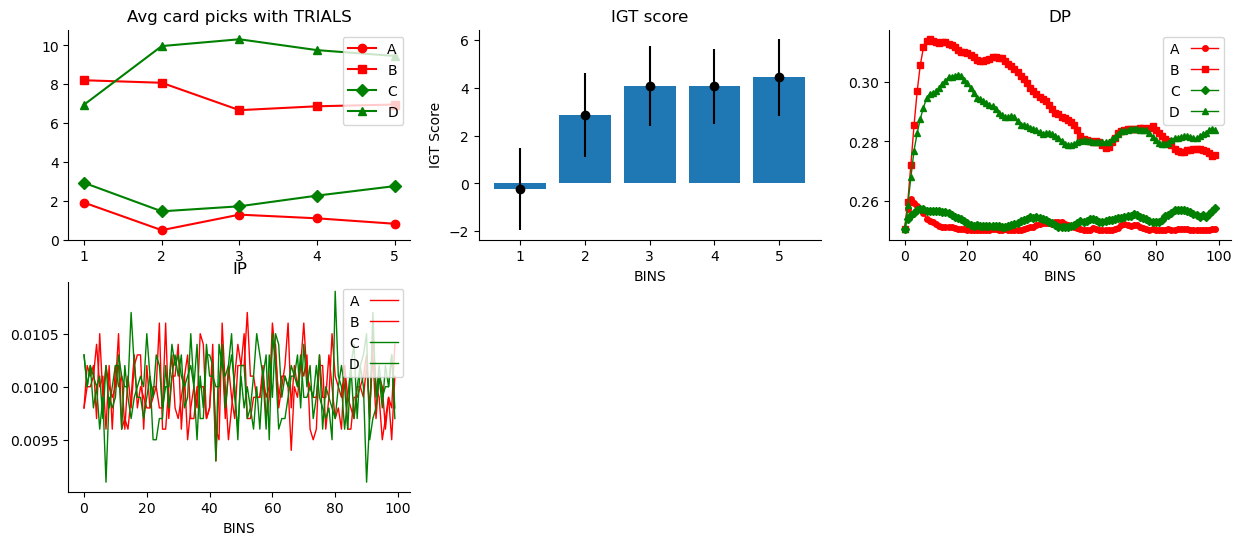

In [34]:
BINS = np.arange(5) + 1
colors = ['red', 'red', 'green', 'green']
arms = ['A', 'B', 'C', 'D']
marker = ['o', 's', 'D', '^']
plt.figure(figsize=(15,6))
plt.subplot(231)
plt.plot(BINS,Avg_A_picks, label = 'A', color = 'red', marker = 'o')
plt.plot(BINS,Avg_B_picks, label = 'B', color = 'red', marker = 's')
plt.plot(BINS,Avg_C_picks, label = 'C', color = 'green', marker = 'D')
plt.plot(BINS,Avg_D_picks, label = 'D', color = 'green', marker = '^')
plt.title('Avg card picks with TRIALS')
plt.legend(loc = 'upper right')

plt.subplot(232)
plt.bar(BINS, IGT_score.reshape(5))
plt.errorbar(BINS, IGT_score.reshape(5), yerr= IGT_dev.reshape(5), fmt='o', color = 'black')
plt.title(f'IGT score')
plt.xlabel('BINS')
plt.ylabel('IGT Score')

plt.subplot(233)
for i in range(DP_all.shape[0]):
    plt.plot(DP_all[i], color = colors[i], label = arms[i], marker = marker[i], linewidth = 1,markersize = 4)
plt.title('DP')
plt.xlabel('BINS')
plt.legend(loc = 'upper right', markerfirst = False)

plt.subplot(234)
for i in range(IP_all.shape[0]):
    plt.plot(IP_all[i], color = colors[i], label = arms[i], linewidth = 1)
plt.title('IP')
plt.xlabel('BINS')
plt.legend(loc = 'upper right', markerfirst = False)
# plt.tight_layout()
# remove left ad top border
for ax in plt.gcf().axes:
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)

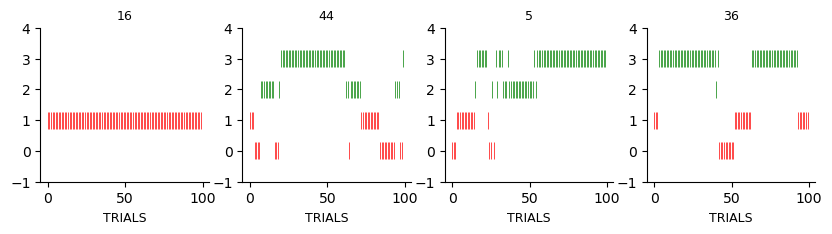

In [35]:
random_pick = np.random.choice(np.arange(EPOCHS), size = 4)

plt.figure(figsize=(10,2))
for i in range(4):
    plt.subplot(1,4,i+1)
    colors = np.where(np.isin(arm_chosen_monitor[random_pick[i]],[0,1]), 'r', 'g')
    # lenght of marker
    plt.scatter(np.arange(TRIALS), arm_chosen_monitor[random_pick[i]], c = colors, s = 150, marker = '|', linewidth = 0.5,)
    plt.ylim(-1,4)
    plt.xlabel('TRIALS', fontsize = 9)
    plt.title(random_pick[i], fontsize = 9)

# remove right border
for ax in plt.gcf().axes:
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)


In [36]:
IGT_expt= np.array([-1.83,1.5,2.6,4.59,3.9])
IGT_Simulated = IGT_score.reshape(5)

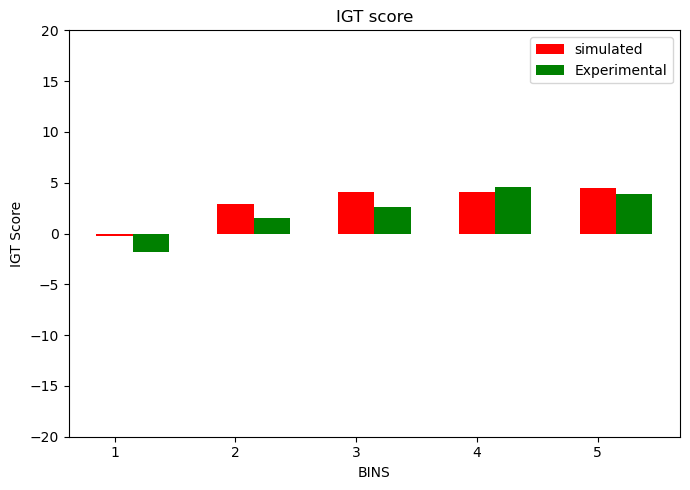

In [37]:
# Plotting bar for IGT
plt.figure(figsize=(7,5))
plt.bar(BINS, IGT_Simulated, width=0.3, color = 'red', label = 'simulated')
plt.bar(BINS+0.3, IGT_expt, width=0.3, color = 'green', label = 'Experimental')
plt.ylim(-20,20)
plt.title(f'IGT score')
plt.xlabel('BINS')
plt.ylabel('IGT Score')
plt.legend()
plt.tight_layout()

In [38]:
# # Comparison each card pick wise
# A_experimental = torch.tensor([4.42,4.12,4.1,4.5,3.68])
# A_simulated = Avg_A_picks.squeeze()

# B_experimental = torch.tensor([6.74,5.35,4.59,3.3,4.57])
# B_simulated = Avg_B_picks.squeeze()

# C_experimental = torch.tensor([4.28,4.34, 4.63,6.64, 5.63])
# C_simulated = Avg_C_picks.squeeze()

# D_experimental = torch.tensor([4.83, 6.48, 6.87, 5.68, 6.39])
# D_simulated = Avg_D_picks.squeeze()

# # Plotting bar chart for card picks
# plt.figure(figsize=(7,5))
# plt.subplot(221)
# plt.bar(BINS, A_experimental, width=0.3, color = 'red', label = 'exp')
# plt.bar(BINS+0.3, A_simulated, width=0.3, color = 'green', label = 'sim')
# plt.ylim(0,15)
# plt.title('Card: A')
# plt.xlabel('BINS')
# plt.ylabel('Card picks')
# plt.legend()

# plt.subplot(222)
# plt.bar(BINS, B_experimental, width=0.3, color = 'red', label = 'exp')
# plt.bar(BINS+0.3, B_simulated, width=0.3, color = 'green', label = 'sim')
# plt.ylim(0,15)
# plt.title('Card: B')
# plt.xlabel('BINS')
# plt.ylabel('Card picks')
# plt.legend()

# plt.subplot(223)
# plt.bar(BINS, C_experimental, width=0.3, color = 'red', label = 'exp')
# plt.bar(BINS+0.3, C_simulated, width=0.3, color = 'green', label = 'sim')
# plt.ylim(0,15)
# plt.title('Card: C')
# plt.xlabel('BINS')
# plt.ylabel('Card picks')
# plt.legend()

# plt.subplot(224)
# plt.bar(BINS, D_experimental, width=0.3, color = 'red', label = 'exp')
# plt.bar(BINS+0.3, D_simulated, width=0.3, color = 'green', label = 'sim')
# plt.ylim(0,15)
# plt.title('Card: D')
# plt.xlabel('BINS')
# plt.ylabel('Card picks')
# plt.legend()

# plt.tight_layout()

In [42]:
mean_sim = IGT_score.squeeze().detach().numpy()
mean_expt = IGT_expt
std_sim = torch.std(torch.add(C_picks, D_picks) - torch.add(A_picks, B_picks), dim = 0).squeeze().detach().numpy()
std_expt = std_sim
n_sim = 100
n_expt = 20

In [43]:
import math
from scipy.stats import t
import pandas as pd

def compare_multiple_pairs(mean_exp, std_exp, n_exp, mean_sim, std_sim, n_sim):
    results = []

    for i in range(len(mean_exp)):
        m1, s1 = mean_exp[i], std_exp[i]
        m2, s2 = mean_sim[i], std_sim[i]

        # Standard error
        se = math.sqrt((s1**2)/n_exp + (s2**2)/n_sim)

        # t-statistic
        t_stat = (m1 - m2) / se

        # Degrees of freedom (Welch-Satterthwaite)
        df_num = (s1**2/n_exp + s2**2/n_sim)**2
        df_den = ((s1**2/n_exp)**2 / (n_exp - 1)) + ((s2**2/n_sim)**2 / (n_sim - 1))
        df = df_num / df_den

        # Two-tailed p-value
        p_val = 2 * (1 - t.cdf(abs(t_stat), df))
        conclusion = "Statistically different" if p_val < 0.05 else "Not statistically different"

        results.append({
            "Index": i+1,
            "Exp Mean": m1,
            "Sim Mean": m2,
            "t-stat": round(t_stat, 3),
            "p-value": round(p_val, 4),
            "Significant": p_val < 0.05,
            "Conclusion": conclusion

        })

    return pd.DataFrame(results)

# Run comparison
df_results_IGT_mean = compare_multiple_pairs(mean_expt, std_expt, n_expt, mean_sim, std_sim, n_sim)

# Show results
# import ace_tools as tools; tools.display_dataframe_to_user(name="Significance Comparison Results", dataframe=df_results)


In [44]:
df_results_IGT_mean

,Index,Exp Mean,Sim Mean,t-stat,p-value,Significant,Conclusion
0,1,-1.83,-0.24,-0.379,0.7079,False,Not statistically different
1,2,1.50,2.86,-0.318,0.7528,False,Not statistically different
2,3,2.60,4.08,-0.362,0.7202,False,Not statistically different
3,4,4.59,4.06,0.136,0.8926,False,Not statistically different
4,5,3.90,4.44,-0.138,0.8911,False,Not statistically different


In [ ]:
# data_normal = {'IGT_sim': mean_sim,
#                'IGT_sim_std': std_sim,
#                'IGT_exp': mean_expt,
#                'IGT_exp_std': std_expt,
#                'n_expt': n_expt,
#                'n_sim': n_sim,
#                'article': 'Gescheidt',
#                'condition': 'normal',
#                'statistical test': df_results_IGT_mean}

# # # saving as pickle file
# # 
# with open('igt_data_normal.pkl', 'wb') as f:
#     pickle.dump(data_normal, f)

In [ ]:
# 